# Radiosonde AI/ML Pipeline

In [74]:
import xarray as xr
import pandas as pd
from pathlib import Path

### Read in precip data

In [75]:
def keep_only_var(ds):
    return ds[["raina_ws800_3m"]]

In [80]:
# Path to the directory of NetCDF files
station_dir = Path("data/ISS_surface/")

# Sorted list of files
station_files = sorted(station_dir.glob("*.nc"))

# Open all files as one dataset
station_ds = xr.open_mfdataset(
    station_files,
    combine="nested",
    concat_dim="time",
    preprocess=keep_only_var,
    drop_variables=["base_time"]
)

# Create a dataframe indexed by time
station_df = (
    station_ds["raina_ws800_3m"]
    .to_dataframe()
    .reset_index()
    .set_index("time")
    .sort_index()
)

# Change from total accumulation to hourly accumulation
station_df["rain_1min"] = station_df["raina_ws800_3m"].diff().fillna(0)
station_df_hourly = station_df["rain_1min"].resample("1h").sum()

<Axes: title={'center': 'Hourly Precip Accumulation during M2HATS'}, xlabel='time'>

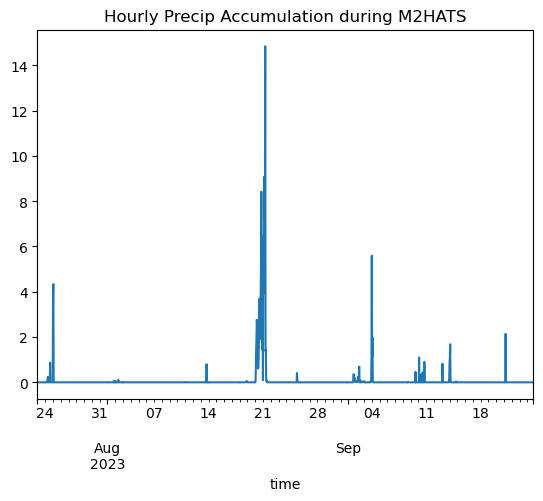

In [84]:
station_df_hourly.plot(title="Hourly Precip Accumulation during M2HATS")

### Read in radiosonde data

In [ ]:
radiosonde_path = Path("/lustre/desc1/scratch/myasears/sounding_data/m2hats")
radiosonde_files = sorted([p for p in radiosonde_path.iterdir() if p.suffix == ".nc"])

In [85]:
# Currently creating gridded zarr file. Will resume after.